## Normalised linear stability spectra

### Packages

In [1]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams.update({'figure.autolayout': True,
                 "text.usetex": True,
                 "font.family": "Computer Modern Roman"})


## Plotting font options ##
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

import numpy as np

import pathlib

import sys
sys.path.append("../")

import dynplot
import Optimisation.opt as opt
from parameters import Parameters
_, L, m, c = Parameters()


l_width = 2.5
colorY = "blue"
colorvY = "dodgerblue"  #cornflowerblue
colorphi = "red"  #"royalblue"
colorvphi = "tomato"  #coral
colorReal = (0.7, 0, 0)
colorImag = 'blue'
colorY2 = "blue"
colorvY2 = "red"  #cornflowerblue
colorphi2 = "black"  #"royalblue"
colorvphi2 = "lightgreen"  #coral

### Calculation

In [9]:
import agfunc

runID = "MdSnpmin20_torcwa"
fname_preamble = '/Users/jlin0351/Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/Doppler Damping - Jadon Lin/Documentation/Data/relativistic-lightsail-dynamics'
speed_range = np.array([0.,20.])
num_points = 400

# Calculate the linear stability information for the chosen grating whose eigenvectors 
# you wish to plot alongside the dynamics
num_cores = 96
# maxfev = 500
maxtime = 2760

pkl_fname = fname_preamble + f'/Optimisation/Jadon\'s results/MdS npmin FoM/final_speed20/maxtime2760/{runID}_FOM_optimisation_maxtime{maxtime}'
_, _, grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=2)
grating.npa = agfunc.agfunc('torch', device='cpu', precision='double')  # twobox.npa wasn't saved during optimisation, must set manually

I = 5e8
restoring_coeffs, damping_coeffs, real_eigvals, imag_eigvals, eigvec_moduli = dynplot.generate_lsa_spectrum(grating, speed_range, I, num_points, normalise=True)

Total function evaluations: 346308
Average function evaluations per core: 3607


### Eigenvalues and eigenvectors

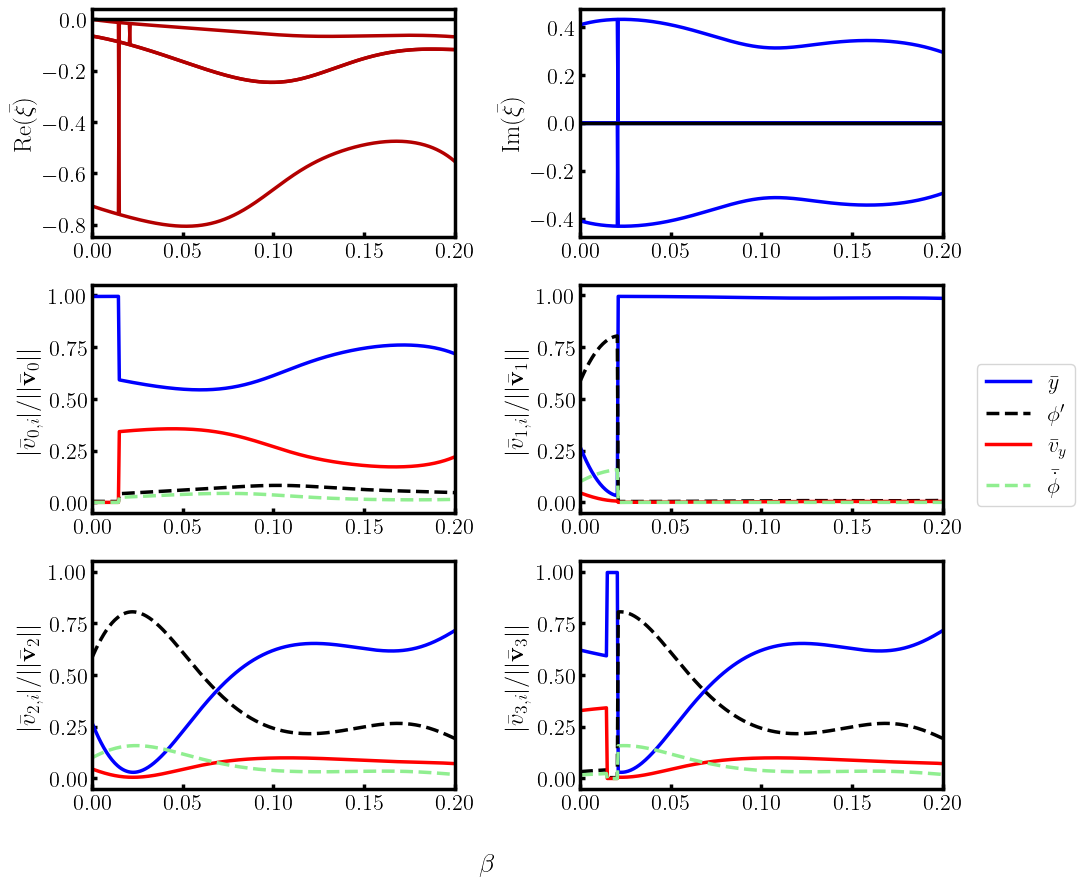

In [10]:
## Convert eigenvalue/vector v array to time
betas = np.linspace(0,0.2, num_points)

# Plot eigenvectors separately
log_axis = False
eigvec_fig, axs = plt.subplots(3,2, figsize=(10,9))

axs_flat = axs.flatten()
axs_flat[0].plot(betas, real_eigvals, color=colorReal, linewidth=l_width)
axs_flat[1].plot(betas, imag_eigvals, color=colorImag, linewidth=l_width)
axs_flat[0].set_yscale('linear')
axs_flat[1].set_yscale('linear')
axs_flat[0].set(xlim=(betas[0],betas[-1]))
axs_flat[1].set(xlim=(betas[0],betas[-1]))
dynplot.show_standard_axes(axs_flat[0], None, xlabel=None, ylabel=r"$\Re(\bar{\xi})$", show_zero_line=True)
dynplot.show_standard_axes(axs_flat[1], None, xlabel=None, ylabel=r"$\Im(\bar{\xi})$", show_zero_line=True)

axs_flat = axs_flat[2:]
# axs_flat[1], axs_flat[2] = axs_flat[2], axs_flat[1]  # switch so that degenerate eigvec magnitudes are shown in columns
for eigvec_idx, ax in enumerate(axs_flat):
    ax.plot(betas, eigvec_moduli[:,0,eigvec_idx], label=r"$\bar{y}$", color=colorY2, linewidth=l_width)
    ax.plot(betas, eigvec_moduli[:,1,eigvec_idx], label=r"$\phi'$", color=colorphi2, linewidth=l_width, linestyle="--")
    ax.plot(betas, eigvec_moduli[:,2,eigvec_idx], label=r"$\bar{v}_y$", color=colorvY2, linewidth=l_width)
    ax.plot(betas, eigvec_moduli[:,3,eigvec_idx], label=r"$\bar{\dot{\phi}}$", color=colorvphi2, linewidth=l_width, linestyle="--")

    if log_axis:
        ax.set(xlim=(betas[0],betas[-1]), ylim=(1e-9,1e1))
        ax.set_yscale('log')
    else:
        ax.set(xlim=(betas[0],betas[-1]), ylim=(-0.05,1.05))
    ax = dynplot.show_standard_axes(ax, None, xlabel=None, ylabel=rf"$|\bar{{v}}_{{{eigvec_idx},i}}|/||\bar{{\mathbf{{v}}}}_{{{eigvec_idx}}}||$", show_zero_line=False)
    

eigvec_fig.supxlabel(r"$\beta$")
handles, labels = ax.get_legend_handles_labels()
leg = eigvec_fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.1,0.5))

# print(imag_eigvals[0:10,:])
# print(real_eigvals[0:10,:])

ftype = ".pdf"
save_fname = fname_preamble + f"/Dynamics/{runID}_eigen" + ftype
eigvec_fig.savefig(save_fname, bbox_inches="tight")

### Jacobian terms spectra

Grouped by acceleration or angular acceleration

In [ ]:
## Combined
LabelSize = 15

################
# Restoring terms
stiff_fig,(ax, ax2) = plt.subplots(1,2,figsize=(15,5))

kyy, kyphi, kphiy, kphiphi = restoring_coeffs.T
muyy, muyphi, muphiy, muphiphi = damping_coeffs.T

ax.plot(betas, kyphi,  label=r"$k^y_\phi$",color=colorY,linestyle="dotted")
ax.plot(betas, kyy,    label=r"$k^y_y$",color=colorY)

ax.set_xlabel(r"$\beta$",fontsize=LabelSize)
ax.set_ylabel(r"Normalised $y$-acceleration ($\partial a_y/\partial q$)",fontsize=LabelSize,color=colorY)
ax.tick_params(labelsize=15)
ax.tick_params(axis='y',labelcolor=colorY)


# ax.hlines(0,0,5,"k","dashed",alpha=0.2)
t = ax.get_ylim()
# ax.axhspan(0,t[1],color='black',alpha=0.2)

ax1 = ax.twinx()
ax1.plot(betas, kphiy,  label=r"$k^\phi_y$",color=colorvphi,linestyle="dotted")
ax1.plot(betas,kphiphi,label=r"$k^\phi_\phi$",color=colorvphi)

ax1.set_ylabel(r"Normalised $\phi$-acceleration ($\partial a_\phi/\partial q$)",fontsize=LabelSize,color=colorvphi)
ax1.tick_params(labelsize=15)
ax1.tick_params(axis='y',labelcolor=colorvphi)


ax.set_ylim(t)
ax.set_xlim(betas[0],betas[-1])

# ax.set_xticks([0,1,1.45,2,3,4,5])

handles, labels = ax.get_legend_handles_labels()
handles1, labels1 = ax1.get_legend_handles_labels()
order = [0,1]
order1=[1,0]
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc=(0.5+0.2,0.5),fontsize=LabelSize)
ax1.legend([handles1[idx] for idx in order1],[labels1[idx] for idx in order1],loc=(0.5,0.5),fontsize=LabelSize)

########################
ax2.plot(betas,muyphi, label=r"$\mu^y_\phi$", color=colorY,linestyle="dotted")
ax2.plot(betas,muyy, label=r"$\mu^y_y$",color=colorY)
ax2
ax2.set_xlabel(r"$\beta$",fontsize=LabelSize)
ax2.set_ylabel(r"Normalised y-acceleration ($\partial a_y/\partial v_q$)", fontsize=LabelSize, color=colorY)
ax2.tick_params(labelsize=15)
ax2.tick_params(axis='y', labelcolor=colorY)

t=ax2.get_ylim()
ax2b=ax2.twinx()

ax2b.plot(betas,muphiy, label=r"$\mu^\phi_y$",color=colorvphi,linestyle="dotted")
ax2b.plot(betas,muphiphi, label=r"$\mu^\phi_\phi$", color=colorvphi)


ax2b.set_ylabel(r"Normalised $\phi$-acceleration ($\partial a_\phi/\partial v_q$)",fontsize=LabelSize,color=colorvphi)
ax2b.tick_params(labelsize=15)
ax2b.tick_params(axis='y',labelcolor=colorvphi)

# # Does not correspond to 1.28%
# ax.vlines(1.4507253626813408,t[0],0,color='k',linestyle='dashed',alpha=0.2)
# ax.hlines(0,0,1.4507253626813408,color='k',linestyle='dashed',alpha=0.2)

ax2.set_ylim(t)
ax2.set_xlim(betas[0],betas[-1])

# ax.set_xticks([0,1,1.45,2,3,4,5])
 
handles, labels = ax2.get_legend_handles_labels()
handles1, labels1 = ax2b.get_legend_handles_labels()
order = [0,1]
order1=[1,0]
ax2.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc=(0.5+0.2,0.5),fontsize=LabelSize)
ax2b.legend([handles1[idx] for idx in order1],[labels1[idx] for idx in order1],loc=(0.5,0.5),fontsize=LabelSize)

stiff_fig.tight_layout()
ftype = ".pdf"
save_fname = fname_preamble + f"/Dynamics/{runID}_jacobian_coefficients" + ftype
# stiff_fig.savefig(save_fname, bbox_inches="tight")